In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the real velocity CSV file
real_velocity_df = pd.read_csv('real_velocity.csv')  # Replace with your real velocity CSV file

# Initialize a DataFrame to store accuracy results
accuracy_df = pd.DataFrame(columns=['Parameters', 'Accuracy'])

# Function to calculate normalized RMSE between real and generated velocities
def calculate_normalized_rmse(real, generated):
    rmse = np.sqrt(np.mean((real - generated)**2))
    target_range = np.max(real) - np.min(real)
    normalized_rmse = rmse / target_range
    return 1 - normalized_rmse  # To make it an accuracy-like metric

# List of generated velocity CSV files
generated_files = ['Predicted_velocity/Lucas-Kanade/Shi-Tomasi.csv', 'Predicted_velocity/Lucas-Kanade/Harris.csv', 'Predicted_velocity/Lucas-Kanade/FAST.csv']

# Loop through each generated velocity file
for generated_file in generated_files:
    # Load the generated velocity CSV file
    generated_df = pd.read_csv(generated_file)

    # Extract the column name for velocity ('v')
    velocity_column_name = [col for col in generated_df.columns if 'v' in col.lower()][0]

    # Merge real and generated DataFrames based on the common index (assuming the DataFrames have the same length)
    merged_df = pd.merge(real_velocity_df, generated_df, left_index=True, right_index=True)

    # Calculate accuracy for each row and average accuracy for the entire set
    merged_df['Accuracy'] = calculate_normalized_rmse(merged_df['velocity'], merged_df[velocity_column_name])

    # Calculate average accuracy for the entire set of parameters
    average_accuracy = merged_df['Accuracy'].mean()

    # Append the results to the accuracy DataFrame
    accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)

# Save the accuracy results to a new CSV file
accuracy_df.to_csv('accuracy_results.csv', index=False)

# Display the accuracy results
print(accuracy_df)


                                       Parameters  Accuracy
0  Predicted_velocity/Lucas-Kanade/Shi-Tomasi.csv  0.759221
1      Predicted_velocity/Lucas-Kanade/Harris.csv  0.759139
2        Predicted_velocity/Lucas-Kanade/FAST.csv  0.758954


C:\Users\DELL\AppData\Local\Temp\ipykernel_492\1319555677.py:39: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_492\1319555677.py:39: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_492\1319555677.py:39: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'Accuracy': average_accuracy}, ignore_index=True)


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the real velocity CSV file
real_velocity_df = pd.read_csv('real_velocity.csv')  # Replace with your real velocity CSV file

# Initialize a DataFrame to store accuracy results
accuracy_df = pd.DataFrame(columns=['Parameters', 'RMSE', 'MAE', 'R2 Score'])

# Function to calculate normalized RMSE between real and generated velocities
def calculate_normalized_rmse(real, generated):
    rmse = np.sqrt(np.mean((real - generated)**2))
    target_range = np.max(real) - np.min(real)
    normalized_rmse = rmse / target_range
    return 1 - normalized_rmse  # To make it an accuracy-like metric

# List of generated velocity CSV files
generated_files = ['Predicted_velocity/Lucas-Kanade/Shi-Tomasi.csv', 'Predicted_velocity/Lucas-Kanade/Harris.csv', 'Predicted_velocity/Lucas-Kanade/FAST.csv']

# Loop through each generated velocity file
for generated_file in generated_files:
    # Load the generated velocity CSV file
    generated_df = pd.read_csv(generated_file)

    # Extract the column name for velocity ('v')
    velocity_column_name = [col for col in generated_df.columns if 'v' in col.lower()][0]

    # Merge real and generated DataFrames based on the common index (assuming the DataFrames have the same length)
    merged_df = pd.merge(real_velocity_df, generated_df, left_index=True, right_index=True)

    # Calculate metrics for each row
    rmse = np.sqrt(mean_squared_error(merged_df['velocity'], merged_df[velocity_column_name]))
    mae = mean_absolute_error(merged_df['velocity'], merged_df[velocity_column_name])
    r2 = r2_score(merged_df['velocity'], merged_df[velocity_column_name])

    # Append the results to the accuracy DataFrame
    accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}, ignore_index=True)

# Save the accuracy results to a new CSV file
# accuracy_df.to_csv('accuracy_results.csv', index=False)




C:\Users\DELL\AppData\Local\Temp\ipykernel_11796\977405390.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11796\977405390.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}, ignore_index=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11796\977405390.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  accuracy_df = accuracy_df.append({'Parameters': generated_file, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}, ignore_index=True)


In [4]:
# Display the accuracy results
accuracy_df

,Parameters,RMSE,MAE,R2 Score
0,Predicted_velocity/Lucas-Kanade/Shi-Tomasi.csv,2715.193026,1054.220991,-0.174268
1,Predicted_velocity/Lucas-Kanade/Harris.csv,2716.124038,1054.788390,-0.175073
2,Predicted_velocity/Lucas-Kanade/FAST.csv,2718.208297,1056.527519,-0.176877


# Lucas-Kanade/Shi-Tomasi

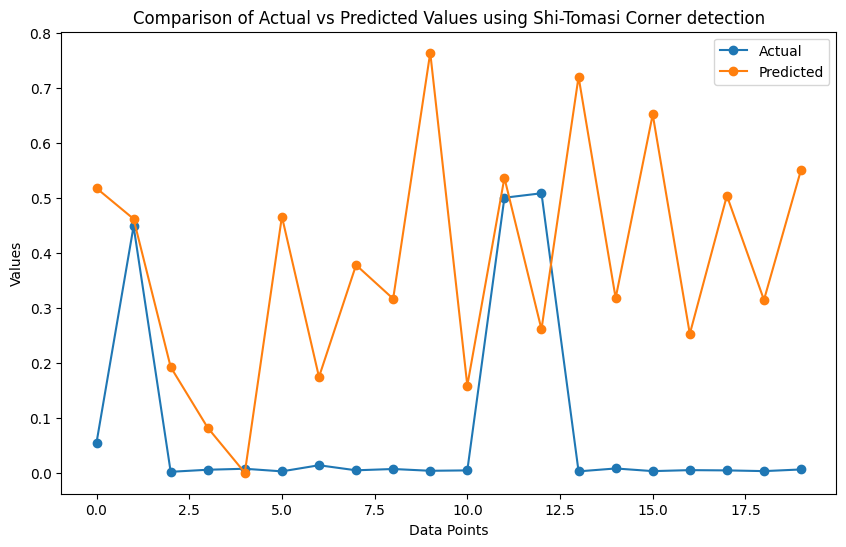

In [31]:
real_velocity_df = pd.read_csv('normalized_real_velocity.csv')  

df = pd.read_csv('Normalized_Predicted_velocity/Shi-Tomasi.csv')  

first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df['v'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values using Shi-Tomasi Corner detection')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Lucas-Kanade/Harris

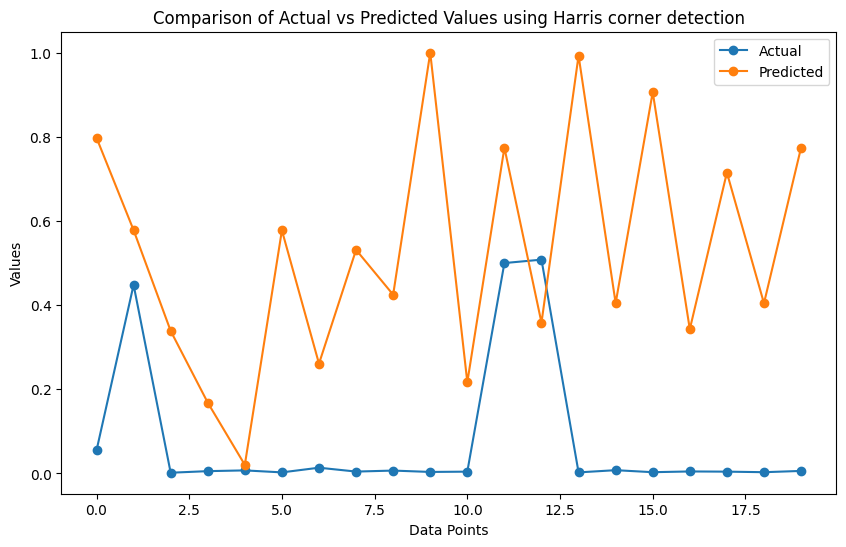

In [32]:
df1 = pd.read_csv('Normalized_Predicted_velocity/Harris.csv')  # Replace with your real velocity CSV file

first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df1['v'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values using Harris corner detection')

# Add legend
plt.legend()

# Show the plot
plt.show()


# Lucas-Kanade/FAST

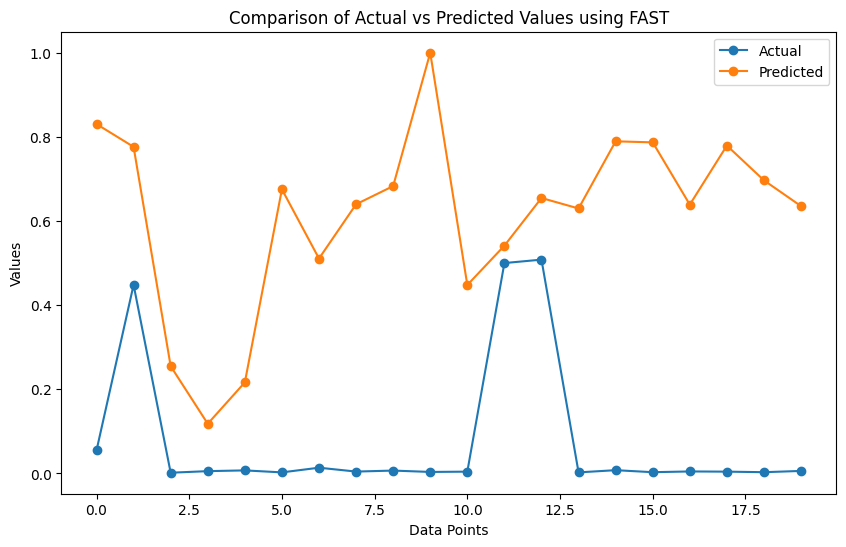

In [9]:
df1 = pd.read_csv('Normalized_Predicted_velocity/FAST.csv')  # Replace with your real velocity CSV file

first_20_samples = real_velocity_df['velocity'].head(20)
first_20_samples_df = df1['v'].head(20)

# Plotting a line chart with a larger figure
index = np.arange(len(first_20_samples))

# Specify the figsize parameter for a larger figure
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(index, first_20_samples, label='Actual', marker='o')
plt.plot(index, first_20_samples_df, label='Predicted', marker='o')

# Add labels and title
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('Comparison of Actual vs Predicted Values using FAST')

# Add legend
plt.legend()

# Show the plot
plt.show()
